In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load the Data(CSV File)
df = pd.read_csv("street_performer_tips.csv")
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 256 entries, 0 to 255
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Performance Hours  252 non-null    float64
 1   Crowd Size (avg)   256 non-null    int64  
 2   tricks_per_hour    256 non-null    int64  
 3   weekend            256 non-null    int64  
 4   weather_score      253 non-null    float64
 5   costume_quality    256 non-null    int64  
 6   interaction_level  256 non-null    int64  
 7   location_type      254 non-null    str    
 8   daily_tips         253 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 18.1 KB


In [3]:
# Clean Column names
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_').str.replace(r'[()]', '', regex=True)
df['location_type'] = df['location_type'].str.strip().str.lower().str.replace(' ','_')
# Optional: Fix any accidental double underscores caused by multiple spaces
df["location_type"] = df["location_type"].str.replace('__', '_')
print(df["location_type"].value_counts())
print(df["location_type"].value_counts().unique().sum())


location_type
subway          71
market          64
tourist_spot    63
park            56
Name: count, dtype: int64
254


In [4]:
df = df.dropna(subset=["daily_tips", "location_type"]).copy()
# Drop duplicates
df = df.drop_duplicates().reset_index(drop=True)
print(df.isnull().sum())
print(df.describe())

performance_hours    4
crowd_size_avg       0
tricks_per_hour      0
weekend              0
weather_score        3
costume_quality      0
interaction_level    0
location_type        0
daily_tips           0
dtype: int64
       performance_hours  crowd_size_avg  tricks_per_hour     weekend  \
count         241.000000      245.000000       245.000000  245.000000   
mean            4.435685       39.865306         9.922449    0.355102   
std             2.312334       22.411626         4.535618    0.487996   
min             1.000000        8.000000         3.000000    0.000000   
25%             2.000000       27.000000         6.000000    0.000000   
50%             4.000000       37.000000        10.000000    0.000000   
75%             6.000000       47.000000        14.000000    1.000000   
max            14.000000      250.000000        17.000000    2.000000   

       weather_score  costume_quality  interaction_level  daily_tips  
count     242.000000       245.000000         245.0

1. Weekend has 0 and 1 so 2 is out of question.
2. daily tips cant be negative
3. interaction cant be negative 
4. costume quality is maxed/capped at 10 out 10 so how can one get 15 
5. Performance_hours has 4 missing values (median can solve it)
6. Weather_score also has missing values  (groupby location_type and median can solve)

In [5]:
df['weekend']= df['weekend'].replace(2,1)
df = df[df['daily_tips'] >= 0]                      # No negative tips
df = df[df['interaction_level'] >= 0]               # No negative interaction
df['costume_quality']= df['costume_quality'].clip(upper=10) #cap at 10
df['performance_hours']= df['performance_hours'].fillna(df['performance_hours'].median())
df['weather_score'] = df['weather_score'].fillna(df.groupby('location_type')['weather_score'].transform('median'))
# Remove extreme tip outliers that warp the linear regression line
df = df[df['daily_tips'] <= 400]


print(f"Cleaned shape: {df.shape}")
print(df.isnull().sum())
print(df.info())

Cleaned shape: (242, 9)
performance_hours    0
crowd_size_avg       0
tricks_per_hour      0
weekend              0
weather_score        0
costume_quality      0
interaction_level    0
location_type        0
daily_tips           0
dtype: int64
<class 'pandas.DataFrame'>
Index: 242 entries, 0 to 244
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   performance_hours  242 non-null    float64
 1   crowd_size_avg     242 non-null    int64  
 2   tricks_per_hour    242 non-null    int64  
 3   weekend            242 non-null    int64  
 4   weather_score      242 non-null    float64
 5   costume_quality    242 non-null    int64  
 6   interaction_level  242 non-null    int64  
 7   location_type      242 non-null    str    
 8   daily_tips         242 non-null    float64
dtypes: float64(3), int64(5), str(1)
memory usage: 18.9 KB
None


Let's Check Which value correlates(Relates) to Daily Tip and By How much so we can understand relationships and maximize Daily_tips

In [6]:
print("\n--- Correlation with daily_tips ---")
print(df.select_dtypes(include='number').corr()['daily_tips'].sort_values(ascending=False))


--- Correlation with daily_tips ---
daily_tips           1.000000
performance_hours    0.510379
interaction_level    0.384109
weekend              0.373007
crowd_size_avg       0.310400
costume_quality      0.172642
weather_score        0.128712
tricks_per_hour      0.067309
Name: daily_tips, dtype: float64


Lets Visualize Occurances of each event and how many times with Histogram

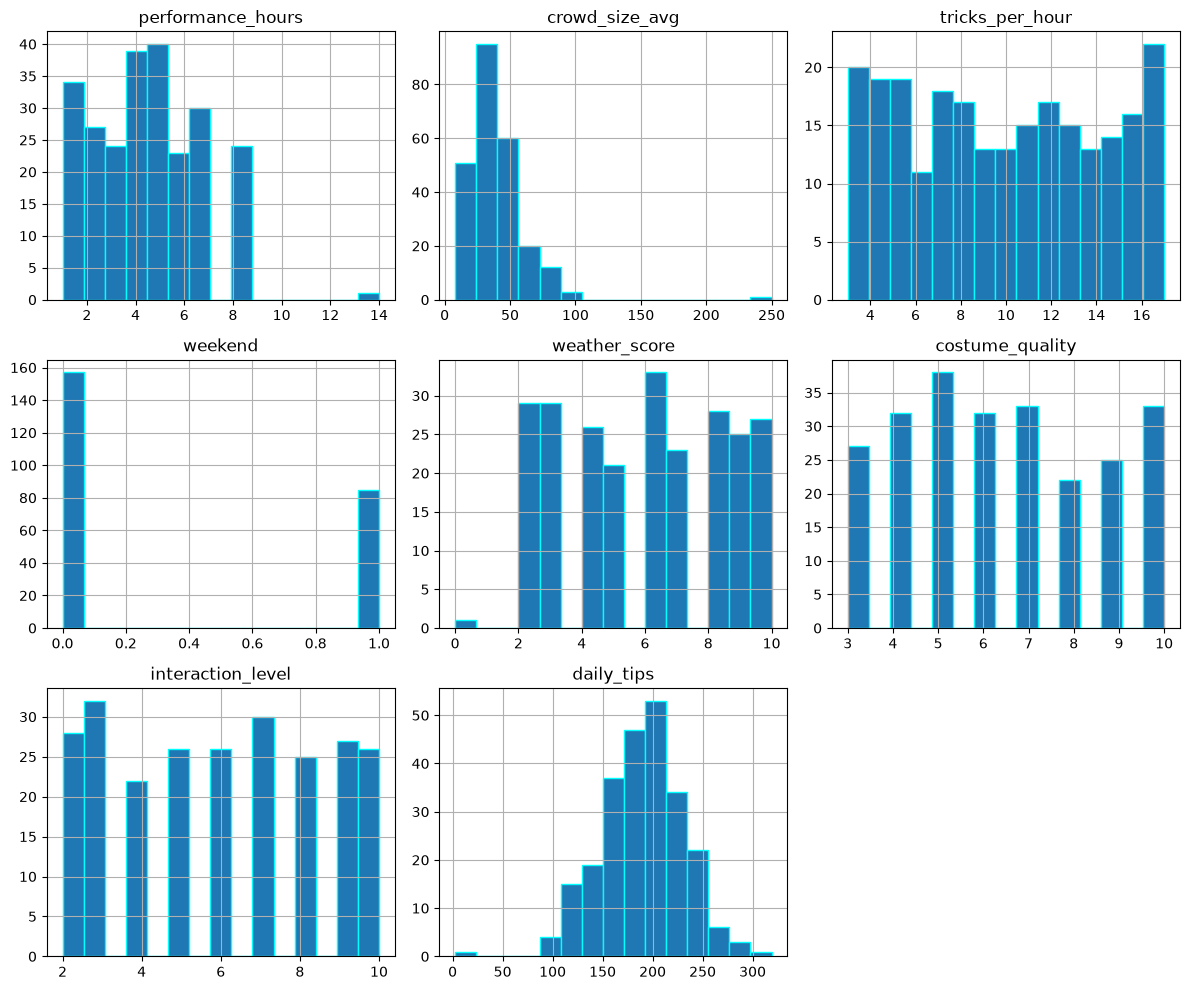

In [8]:
df.hist(bins=15 , figsize=(12,10),edgecolor='cyan')
plt.tight_layout()
plt.savefig('Histogram_DailyTips.png')
plt.show()

In [9]:
df_encoded = pd.get_dummies(df, columns=['location_type'], drop_first=True) #

X = df_encoded.drop('daily_tips', axis=1)
y = df_encoded['daily_tips']


Split

In [10]:
# SPLIT records into training Data 80% and Testing Data to see minimized amount of error with 20% of testing data 

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)


Model Making And Predictions

In [12]:

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

1.Find Out R2 score, Mean Absolute errors, mean squared error abd Root Mean Squared Error 
2. Coefficients should be known as well

In [13]:
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse= mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print(f"\nR² Score: {r2:.4f}")
print(f"MAE: ${mae:,.2f} (average miss)")
print(f"MSE: ${mse:,.2f} (squared error)")
print(f"RMSE: ${rmse:,.2f} (typical error)")



R² Score: 0.9068
MAE: $10.98 (average miss)
MSE: $190.51 (squared error)
RMSE: $13.80 (typical error)


Another method for r2

In [18]:
from sklearn.model_selection import cross_val_score

# 1. We use the full X and y datasets (no train/test split needed here)
# 2. cv=5 means it shuffles and tests the data 5 separate times
scores = cross_val_score(LinearRegression(), X, y, cv=10, scoring='r2')

print("--- 10-Fold Cross-Validation R² Scores ---")
print(scores)
print(f"True Average R² Score: {scores.mean():.4f}")


--- 10-Fold Cross-Validation R² Scores ---
[0.8306887  0.88011479 0.86287193 0.67777686 0.52177797 0.71960891
 0.85115632 0.33180368 0.8721746  0.85941679]
True Average R² Score: 0.7407


In [19]:
#  COEFFICIENTS

print("\n--- Feature Impacts on Salary ---")
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', ascending=False)

for _, row in coef_df.iterrows():
    direction = "↑ increases" if row['Coefficient'] > 0 else "↓ decreases"
    print(f"{row['Feature']:30s}: {row['Coefficient']:+12.2f}  ({direction})")

print(f"\nBase salary (intercept): ${model.intercept_:,.2f}")




--- Feature Impacts on Salary ---
weekend                       :       +26.82  (↑ increases)
location_type_tourist_spot    :       +22.49  (↑ increases)
performance_hours             :        +8.19  (↑ increases)
interaction_level             :        +5.72  (↑ increases)
costume_quality               :        +3.73  (↑ increases)
weather_score                 :        +3.58  (↑ increases)
tricks_per_hour               :        +1.58  (↑ increases)
crowd_size_avg                :        +0.14  (↑ increases)
location_type_subway          :        -3.66  (↓ decreases)
location_type_park            :       -23.34  (↓ decreases)

Base salary (intercept): $44.28


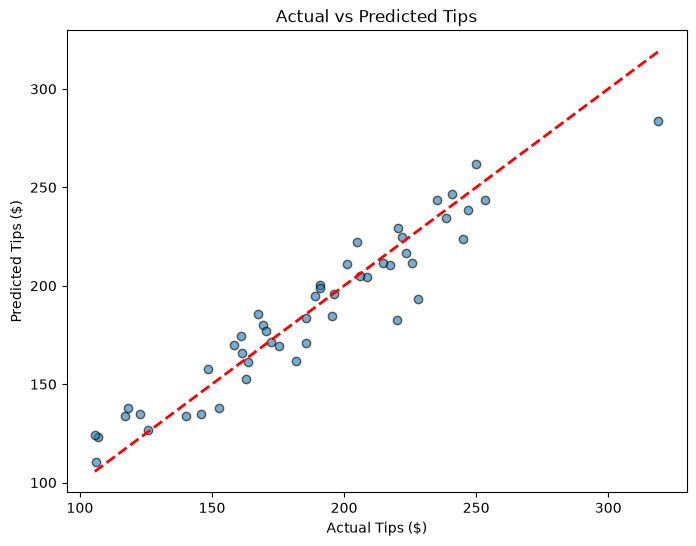

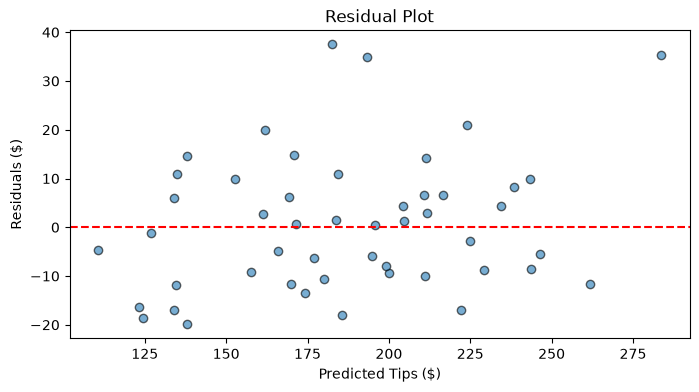

In [20]:

# 13. VISUALIZE

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6, edgecolors='k')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Tips ($)")
plt.ylabel("Predicted Tips ($)")
plt.title("Actual vs Predicted Tips")
plt.show()

# errors/residuals
errors = y_test - y_pred
plt.figure(figsize=(8, 4))
plt.scatter(y_pred, errors, alpha=0.6, edgecolors='k')
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel("Predicted Tips ($)")
plt.ylabel("Residuals ($)")
plt.title("Residual Plot")
plt.show()

daily_tips           1.000000
performance_hours    0.510379
interaction_level    0.384109
weekend              0.373007
crowd_size_avg       0.310400
costume_quality      0.172642
weather_score        0.128712
tricks_per_hour      0.067309
Name: daily_tips, dtype: float64


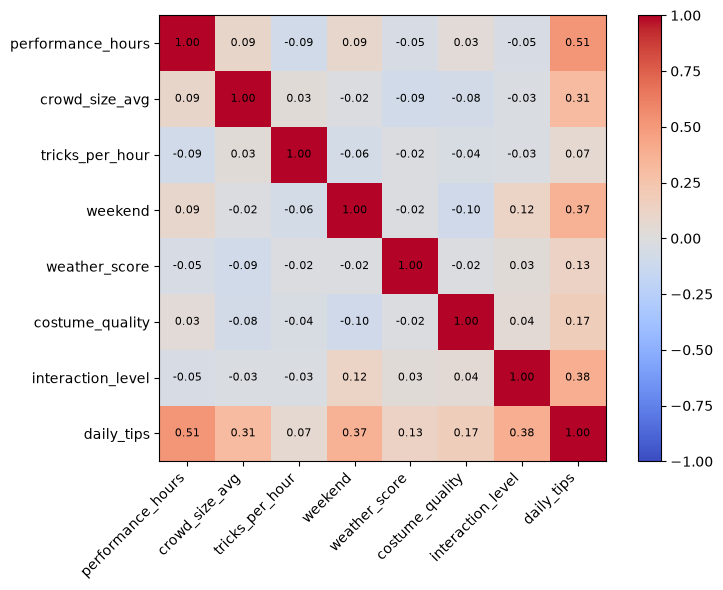

In [22]:
# ... existing code ...

corr = df.corr(numeric_only=True)

# which features actually track the target?
print(corr['daily_tips'].sort_values(ascending=False))

# heatmap
fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(corr, cmap='coolwarm', vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right')
ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=8)
fig.colorbar(im)
plt.tight_layout()
plt.savefig('Heatmap_StreetPerformer.png')
plt.show()

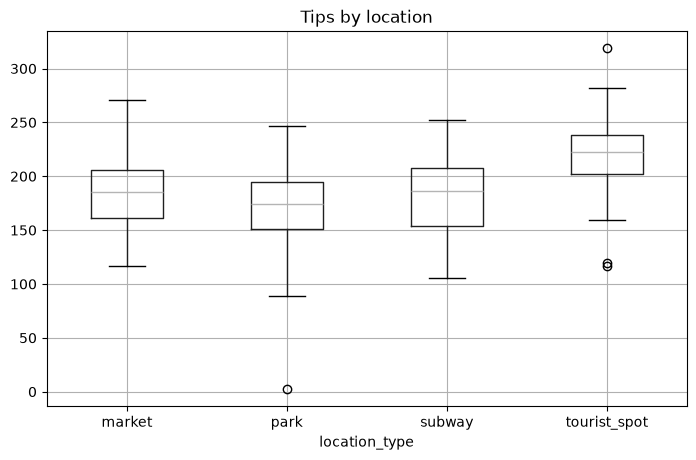

In [23]:
# ... existing code ...

df.boxplot(column='daily_tips', by='location_type', figsize=(8, 5))
plt.suptitle('')
plt.title('Tips by location')

plt.show()
